# `Void Probability Function and 1NN-CDF` Tutorial

**Author**: Eishica Chand (email:[eishica.chand@students.iiserpune.ac.in](mailto:eishica.chand@students.iiserpune.ac.in))
\
**Date**: 21 July 2026\
**kNNpy version**: 0.0.1


<a name="imports" id="imports"></a>
## Imports and Setup


In [1]:
#Importing external libraries

import numpy as np
from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors
import readfof
import readgadget
import copy
import MAS_library as MASL
import os
import sys
import warnings
from scipy.special import factorial
from matplotlib.ticker import MaxNLocator
from scipy.spatial import cKDTree

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('..'))           # '../../' is needed because the parent directory is two directories upstream of this test directory

if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf
from kNNpy import kNN_3D


<a name="plot-prefs" id="plot-prefs"></a>
### Plotting Preferences

We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `usetex=False` if you do not have $\LaTeX$ installed.


In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 15})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
# BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']
c      =  ["#630A0A", "#0D156A", "#128712", "#2D8498", "#A41B92",  "#D76F33", "#5C558A", "#2F1728", '#D7A633', '#5C8A55', '#2F8A17']


## Function

### kNN-CDF measurements

In [3]:
def knnCdf(pos_data, Lbox, kn, query_pos, r):
    """
    Computes the kNN CDF for a given set of data points and query points.

    Parameters:
    pos_data : array_like
        The positions of the data points in 3D space.
    Lbox : float
        The size of the box (assumed to be cubic).
    kn : int
        The number of nearest neighbors to consider.
    query_pos : array_like
        The positions of the query points in 3D space.
    r : array_like
        The radii at which to compute the CDF.

    Returns:
    auto_cdf : array_like
        The computed kNN CDF values.
    """
    
    # Create a KD-tree for efficient neighbor searching
    halo_tree   =    cKDTree(pos_data, boxsize=Lbox)
    h_dists, _  =    halo_tree.query(query_pos, k=kn, workers=-1)
    h_dists     =    h_dists.astype(np.float32)
    kNN_mask    =    h_dists[:, None] <= r[None, :]         # Vectorized over r: shape (n_quer, kn, len_r)
    auto_cdf    =    np.mean(kNN_mask, axis=0)     

    return auto_cdf

### Theoretical form of VPF for a random Poisson distribution

In [4]:
def Vpf_Poisson(nbar, r):

    """
    Computes the Poisson VPF for a given number density and radius.

    Parameters
    ----------
    nbar : float
        The number density of the sample.
    r : float
        The radius of the sphere.

    Returns
    -------
    vpf : float
        The Poisson VPF for the given number density and radius.
    """

    vpf = np.exp(-nbar * (4/3) * np.pi * r**3)
    
    return vpf

## Main

<a name="mock" id="mock"></a>

### Measurement of VPF (through 1NN-CDF) on a Poisson distributed dataset and its comparison to the theoretical value


In [5]:
# Number of data points
r    =  np.linspace(5.,30.,10).astype(np.float32) #Mpc/h ; radius of sphere
Np   =  100000
Lbox =  1000.0 #Mpc/h ; size of box

# particle positions in 3D
Rndm_pos = np.random.random((Np,3)).astype(np.float32)*Lbox
Rndm_pos = np.mod(Rndm_pos, Lbox) #periodic boundary conditions
print(f"Min and Max of the random positions: {np.min(Rndm_pos,axis=0)}, {np.max(Rndm_pos,axis=0)}")
print(f"Average Inter Particle Separation~", (Lbox**3/Np)**(1/3))

Min and Max of the random positions: [0.01481445 0.02962673 0.00082568], [999.97943 999.99524 999.98535]
Average Inter Particle Separation~ 21.544346900318832


<a name="query-points" id="query-points"></a>
### Generate Query Points

The query points are the locations from which the nearest-neighbour distances are computed. 

In [6]:
QueryPos    = hf.create_query_3D('random', 256, Lbox)
QueryPos    = QueryPos.astype(np.float32)
QueryPos    = np.mod(QueryPos, Lbox) #periodic boundary conditions
print(f"Min and Max of the random query positions: {np.min(QueryPos,axis=0)}, {np.max(QueryPos,axis=0)}")
print(f"Average Inter Query Separation~", (Lbox**3/len(QueryPos))**(1/3))

Min and Max of the random query positions: [2.2182354e-05 2.0903188e-05 8.3426465e-05], [999.9998  999.99994 999.99994]
Average Inter Query Separation~ 3.9062499999999996


In [7]:
Rndms_1nnCdf_a = kNN_3D.TracerAuto3D(Lbox, [1], [r], QueryPos, Rndm_pos)[0][0]


In [8]:
# Faster
Rndms_1nnCdf =  knnCdf(Rndm_pos, Lbox, 1, QueryPos, r)


In [9]:
print(f"Max abs diff between the two methods: {np.max(np.abs(Rndms_1nnCdf - Rndms_1nnCdf_a))}")

Max abs diff between the two methods: 1.8302912097034607e-07


#### Plotting the 1NN-CDF

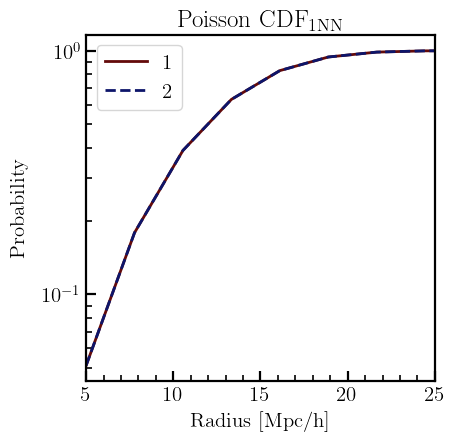

In [10]:
plt.figure(figsize=(4.5, 4.5))

plt.plot(r, Rndms_1nnCdf, color = c[0], lw=2, label=f'1')
plt.plot(r, Rndms_1nnCdf_a, color = c[1], lw=2, ls='--', label=f'2')
         
plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'Probability', labelpad=10)
plt.title(r"Poisson $\rm {CDF}_{1NN}$")
plt.yscale('log')
plt.xlim(5,25)
plt.legend()
plt.show()
plt.close()

### VPF

In [11]:
nbar = Np/(Lbox**3)
vpf_Poisson = Vpf_Poisson(nbar, r)

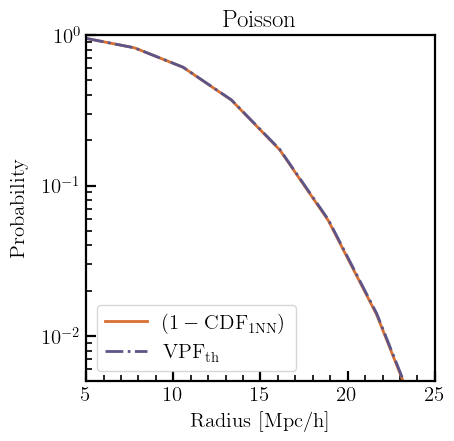

In [12]:
plt.figure(figsize=(4.5, 4.5))

plt.plot(r, 1 - Rndms_1nnCdf, color = c[5], lw=2, label=r'$(1- \rm {CDF}_{1NN})$')
plt.plot(r, vpf_Poisson, color = c[6], lw=2, ls='-.', label=r'$\rm {VPF}_{th}$')
         
plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'Probability', labelpad=10)
plt.title(f"Poisson")
plt.yscale('log')
plt.xlim(5,25)
plt.ylim(5e-3,1.001)
plt.legend()

plt.show()
plt.close()

<a name="mock" id="mock"></a>

### Loading Halo Catalog at Redshift $z=0$  [Quijote simulations](https://quijote-simulations.readthedocs.io/en/latest/).


In [13]:
DataPath='../kNNpy/Data'

snapnum, redshift = 4,0            # saving convention of Quijote
halo_dir =  f"{DataPath}/Quijote_simulations/fiducial_LR/0"

# read the halo catalogue
FoF = readfof.FoF_catalog(halo_dir, snapnum, long_ids=False,swap=False, SFR=False, read_IDs=False)

# get the properties of the halos
pos_halo      =     FoF.GroupPos/1e3            #Halo positions in Mpc/h
pos_halo      =     pos_halo.astype(np.float32)
mass_halo     =     FoF.GroupMass*1e10          #Halo masses in Msun/h

print(f"Informations about the halo catalogue at z={redshift}:")
print(f"Number of halos: {len(pos_halo)}")
print(f"Mass range: {np.min(mass_halo):.2e} - {np.max(mass_halo):.2e} Msun/h")
print(f"Position range: {np.min(pos_halo,axis=0)} - {np.max(pos_halo,axis=0)} Mpc/h")

Informations about the halo catalogue at z=0:
Number of halos: 406660
Mass range: 1.31e+13 - 5.47e+15 Msun/h
Position range: [0.00017787 0.00561007 0.00248465] - [999.996  999.9956 999.9966] Mpc/h


#### Select the Np Most Massive Halos

In [14]:
# Select Np most massive halos for the analysis
idx           = np.argsort(mass_halo)[::-1][:Np]
pos_halo_use  = pos_halo[idx]
mass_halo_use = mass_halo[idx]

print(f"Number of halos: {len(pos_halo_use)}")
print(f"Mass range: {np.min(mass_halo_use):.2e} - {np.max(mass_halo_use):.2e} Msun/h")
print(f"Position range: {np.min(pos_halo_use,axis=0)} - {np.max(pos_halo_use,axis=0)} Mpc/h")


Number of halos: 100000
Mass range: 4.66e+13 - 5.47e+15 Msun/h
Position range: [0.00849513 0.01377274 0.00263293] - [999.98865 999.99554 999.9966 ] Mpc/h


In [15]:
# Halos 1NNCDF
Halos_1nnCdf =  knnCdf(pos_halo_use, Lbox, 1, QueryPos, r)

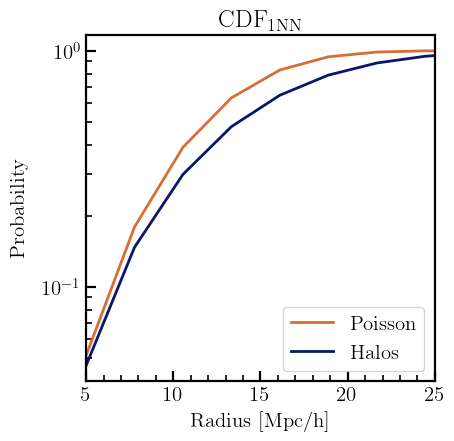

In [16]:
plt.figure(figsize=(4.5, 4.5))

plt.plot(r, Rndms_1nnCdf, color = c[5], lw=2, label=r'Poisson')
plt.plot(r, Halos_1nnCdf, color = c[1], lw=2, label=r'Halos')
     
plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'Probability', labelpad=10)
plt.title(r"$\rm {CDF}_{1NN}$")
plt.yscale('log')
plt.xlim(5,25)
# plt.ylim(5e-3,1.001)
plt.legend()

plt.show()
plt.close()

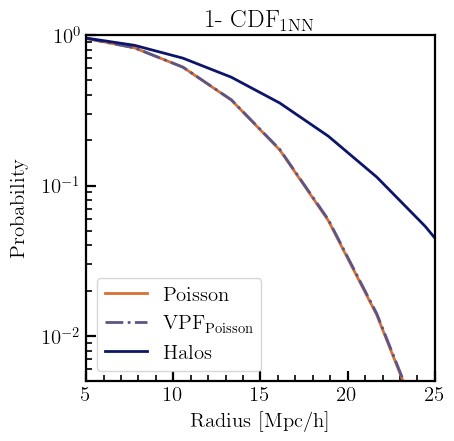

In [17]:
plt.figure(figsize=(4.5, 4.5))

plt.plot(r, 1 - Rndms_1nnCdf, color = c[5], lw=2, label=r'Poisson')
plt.plot(r, vpf_Poisson, color = c[6], lw=2, ls='-.', label=r'$\rm {VPF}_{Poisson}$')
plt.plot(r, 1 - Halos_1nnCdf, color = c[1], lw=2, label=r'Halos')
     
plt.xlabel('Radius [Mpc/h]')
plt.ylabel(r'Probability', labelpad=10)
plt.title(r"1- $\rm {CDF}_{1NN}$")
plt.yscale('log')
plt.xlim(5,25)
plt.ylim(5e-3,1.001)
plt.legend()

plt.show()
plt.close()